In [ ]:
# ============================================================
# VARIANTE A: CLASS WEIGHTING
# ============================================================

import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
import json

# 1. TRAINER PERSONNALISÉ AVEC GESTION DES DEVICES

class WeightedLossTrainer(Trainer):

    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights
        self.loss_fn = None

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Créer la loss sur le même device que les logits
        if self.class_weights is not None:
            # Déplacer les poids sur le device des logits
            device = logits.device
            weights = self.class_weights.to(device)
            loss_fn = nn.CrossEntropyLoss(weight=weights)
        else:
            loss_fn = nn.CrossEntropyLoss()

        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# 2. CALCUL DES POIDS

# Compter les classes dans le train set
class_counts = train_set["Polarity Class"].value_counts()
total_examples = len(train_set)
num_classes = 3

print(f"\nDistribution dans train set:")
for classe, count in class_counts.items():
    print(f"  {classe}: {count} ({count/total_examples*100:.1f}%)")

# Calculer les poids
class_weights_dict = {}
for classe, count in class_counts.items():
    weight = total_examples / (num_classes * count)
    class_weights_dict[classe] = weight

print(f"\nPoids calculés:")
for classe, weight in class_weights_dict.items():
    print(f"  {classe}: {weight:.4f}")

weights_tensor = torch.tensor([
    class_weights_dict["Negative"],
    class_weights_dict["Neutral"],
    class_weights_dict["Positive"]
])

print(f"\nTensor de poids: {weights_tensor.numpy()}")

# 3. CHARGEMENT DU MODÈLE

model_name = "alger-ia/dziribert"

label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {0: "negative", 1: "neutral", 2: "positive"}

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# Vérifier le device du modèle
print(f"\nModèle sur device: {next(model.parameters()).device}")

# 4. PRÉPARATION DES DATASETS


# Ajouter les labels numériques
train_set["label"] = train_set["Polarity Class"].str.lower().map(label2id)
val_set["label"] = val_set["Polarity Class"].str.lower().map(label2id)
test_set["label"] = test_set["Polarity Class"].str.lower().map(label2id)

# Créer les datasets
train_dataset = Dataset.from_pandas(train_set[["clean_text", "label"]])
val_dataset = Dataset.from_pandas(val_set[["clean_text", "label"]])
test_dataset = Dataset.from_pandas(test_set[["clean_text", "label"]])

# Tokenisation
def tokenize_function(example):
    return tokenizer(
        example["clean_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format pour PyTorch
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print(f"\n Datasets préparés:")
print(f"  Train: {len(train_dataset)}")
print(f"  Val: {len(val_dataset)}")
print(f"  Test: {len(test_dataset)}")

# 5. MÉTRIQUES

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    f1_macro = f1_score(labels, predictions, average='macro')
    f1_per_class = f1_score(labels, predictions, average=None)
    precision, recall, _, _ = precision_recall_fscore_support(labels, predictions, average=None)
    accuracy = accuracy_score(labels, predictions)
    g_mean = np.sqrt(np.prod(recall))

    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_negative': f1_per_class[0],
        'f1_neutral': f1_per_class[1],
        'f1_positive': f1_per_class[2],
        'precision_negative': precision[0],
        'precision_neutral': precision[1],
        'precision_positive': precision[2],
        'recall_negative': recall[0],
        'recall_neutral': recall[1],
        'recall_positive': recall[2],
        'g_mean': g_mean
    }

# 6. CONFIGURATION

training_args = TrainingArguments(
    output_dir="./class_weighting_model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    seed=42,
    report_to="none"
)

# 7. ENTRAÎNEMENT

print("\n" + "="*60)
print("ENTRAÎNEMENT AVEC CLASS WEIGHTING")
print("="*60)

# Créer le trainer avec les poids
trainer = WeightedLossTrainer(
    class_weights=weights_tensor,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# Lancer l'entraînement
trainer.train()

# 8. ÉVALUATION

print("\n" + "="*60)
print("ÉVALUATION SUR LE TEST SET")
print("="*60)

test_results = trainer.evaluate(test_dataset)

print("\n RÉSULTATS CLASS WEIGHTING:")
print("-"*50)
print(f"Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"F1-macro: {test_results['eval_f1_macro']:.4f}")
print(f"G-mean: {test_results['eval_g_mean']:.4f}")
print("\nF1 par classe:")
print(f"  Negative: {test_results['eval_f1_negative']:.4f}")
print(f"  Neutral: {test_results['eval_f1_neutral']:.4f} ← Classe minoritaire")
print(f"  Positive: {test_results['eval_f1_positive']:.4f}")

# 9. COMPARAISON AVEC BASELINE

try:
    with open('baseline_results.json', 'r') as f:
        baseline = json.load(f)

    print("\n" + "="*60)
    print("COMPARAISON BASELINE VS CLASS WEIGHTING")
    print("="*60)

    print(f"\n{'Métrique':<20} {'Baseline':>12} {'Class Weight':>12} {'Δ':>10}")
    print("-"*55)

    neutral_improvement = test_results['eval_f1_neutral'] - baseline.get('f1_neutral', 0)

    print(f"{'F1-macro':<20} {baseline.get('f1_macro', 0):>12.4f} {test_results['eval_f1_macro']:>12.4f} {test_results['eval_f1_macro'] - baseline.get('f1_macro', 0):>+10.4f}")
    print(f"{'F1-Neutral':<20} {baseline.get('f1_neutral', 0):>12.4f} {test_results['eval_f1_neutral']:>12.4f} {neutral_improvement:>+10.4f}")
    print(f"{'G-mean':<20} {baseline.get('g_mean', 0):>12.4f} {test_results['eval_g_mean']:>12.4f} {test_results['eval_g_mean'] - baseline.get('g_mean', 0):>+10.4f}")

    print(f"\n Amélioration sur classe Neutral: {neutral_improvement:+.4f} ({neutral_improvement*100:+.1f}%)")

except FileNotFoundError:
    print("\n Baseline non trouvée")

# ============================================================
# 10. SAUVEGARDE
# ============================================================

class_weighting_results = {
    'strategy': 'Class Weighting',
    'class_weights': {
        'negative': float(weights_tensor[0]),
        'neutral': float(weights_tensor[1]),
        'positive': float(weights_tensor[2])
    },
    'metrics': {
        'accuracy': test_results['eval_accuracy'],
        'f1_macro': test_results['eval_f1_macro'],
        'f1_negative': test_results['eval_f1_negative'],
        'f1_neutral': test_results['eval_f1_neutral'],
        'f1_positive': test_results['eval_f1_positive'],
        'g_mean': test_results['eval_g_mean']
    }
}

with open('class_weighting_results.json', 'w') as f:
    json.dump(class_weighting_results, f, indent=4)

print("\n Résultats sauvegardés dans 'class_weighting_results.json'")




Distribution dans train set:
  Positive: 1817 (52.1%)
  Negative: 1215 (34.8%)
  Neutral: 455 (13.0%)

Poids calculés:
  Positive: 0.6397
  Negative: 0.9567
  Neutral: 2.5546

Tensor de poids: [0.95665294 2.5545788  0.63969916]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on


Modèle sur device: cpu


Map:   0%|          | 0/3487 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


ÉVALUATION SUR LE TEST SET



 RÉSULTATS CLASS WEIGHTING:
--------------------------------------------------
Accuracy: 0.7139
F1-macro: 0.6776
G-mean: 0.5555

F1 par classe:
  Negative: 0.7057
  Neutral: 0.5714 ← Classe minoritaire
  Positive: 0.7558

COMPARAISON BASELINE VS CLASS WEIGHTING

Métrique                 Baseline Class Weight          Δ
-------------------------------------------------------
F1-macro                   0.6758       0.6776    +0.0018
F1-Neutral                 0.5561       0.5714    +0.0153
G-mean                     0.5380       0.5555    +0.0176

 Amélioration sur classe Neutral: +0.0153 (+1.5%)

 Résultats sauvegardés dans 'class_weighting_results.json'


In [ ]:
#FOCAL LOSS
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import Trainer
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

print("="*70)
print("STRATÉGIE 1 - VARIANTE B & C: FOCAL LOSS")
print("="*70)

# ============================================================
# 1. DÉFINITION DE FOCAL LOSS
# ============================================================

class FocalLoss(nn.Module):

    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):

        ce_loss = F.cross_entropy(inputs, targets, reduction='none')

        # Probabilité de la classe correcte
        pt = torch.exp(-ce_loss)

        # Focal Loss: (1 - pt)^γ * CE
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        # Application des poids alpha (si fournis)
        if self.alpha is not None:
            # Déplacer alpha sur le même device que targets
            alpha_t = self.alpha.to(targets.device)[targets]
            focal_loss = alpha_t * focal_loss

        return focal_loss.mean()


class FocalLossTrainer(Trainer):
    """
    Trainer personnalisé utilisant Focal Loss
    """
    def __init__(self, gamma=2.0, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.focal_loss = FocalLoss(gamma=gamma, alpha=class_weights)

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = self.focal_loss(logits, labels)
        return (loss, outputs) if return_outputs else loss


# ============================================================
# 2. PRÉPARATION DES MODÈLES ET DONNÉES
# ============================================================

# Réinitialiser le modèle pour chaque expérience
def get_fresh_model():
    """Créer un nouveau modèle DziriBERT non entraîné"""
    from transformers import AutoModelForSequenceClassification, AutoConfig

    config = AutoConfig.from_pretrained(
        "alger-ia/dziribert",
        num_labels=3,
        id2label={0: "negative", 1: "neutral", 2: "positive"},
        label2id={"negative": 0, "neutral": 1, "positive": 2}
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        "alger-ia/dziribert",
        config=config
    )
    return model

# ============================================================
# 3. VARIANTE B: FOCAL LOSS (γ=1)
# ============================================================

print("\n" + "="*60)
print("VARIANTE B - FOCAL LOSS γ=1")
print("="*60)

model_g1 = get_fresh_model()

trainer_g1 = FocalLossTrainer(
    gamma=1.0,
    class_weights=None,  # Pas de poids, uniquement Focal Loss
    model=model_g1,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("\nEntraînement avec Focal Loss γ=1...")
trainer_g1.train()
test_results_g1 = trainer_g1.evaluate(test_dataset)

print("\n RÉSULTATS FOCAL LOSS γ=1:")
print(f"  F1-macro: {test_results_g1['eval_f1_macro']:.4f}")
print(f"  F1-Neutral: {test_results_g1['eval_f1_neutral']:.4f}")

# ============================================================
# 4. VARIANTE B: FOCAL LOSS (γ=2)
# ============================================================

print("\n" + "="*60)
print("VARIANTE B - FOCAL LOSS γ=2")
print("="*60)

model_g2 = get_fresh_model()

trainer_g2 = FocalLossTrainer(
    gamma=2.0,
    class_weights=None,
    model=model_g2,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("\nEntraînement avec Focal Loss γ=2...")
trainer_g2.train()
test_results_g2 = trainer_g2.evaluate(test_dataset)

print("\n RÉSULTATS FOCAL LOSS γ=2:")
print(f"  F1-macro: {test_results_g2['eval_f1_macro']:.4f}")
print(f"  F1-Neutral: {test_results_g2['eval_f1_neutral']:.4f}")


# ============================================================
# TEST FOCAL LOSS AVEC γ=3
# ============================================================

print("="*60)
print("TEST FOCAL LOSS γ=3")
print("="*60)

# Créer un nouveau modèle
model_g3 = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# Trainer avec γ=3
trainer_g3 = FocalLossTrainer(
    gamma=3.0,
    class_weights=None,
    model=model_g3,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# Entraînement
trainer_g3.train()
test_results_g3 = trainer_g3.evaluate(test_dataset)

print(f"\n RÉSULTATS FOCAL LOSS γ=3:")
print(f"  F1-macro: {test_results_g3['eval_f1_macro']:.4f}")
print(f"  F1-Neutral: {test_results_g3['eval_f1_neutral']:.4f}")
print(f"  G-mean: {test_results_g3['eval_g_mean']:.4f}")


STRATÉGIE 1 - VARIANTE B & C: FOCAL LOSS

VARIANTE B - FOCAL LOSS γ=1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on


Entraînement avec Focal Loss γ=1...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Negative,F1 Neutral,F1 Positive,Precision Negative,Precision Neutral,Precision Positive,Recall Negative,Recall Neutral,Recall Positive,G Mean
1,No log,0.420441,0.706827,0.638407,0.688645,0.464789,0.761787,0.657343,0.750000,0.736211,0.723077,0.336735,0.789203,0.438360
2,No log,0.440068,0.714859,0.666975,0.693227,0.543353,0.764347,0.719008,0.626667,0.727907,0.669231,0.479592,0.804627,0.508184
3,0.355664,0.575394,0.709505,0.652486,0.692607,0.500000,0.764851,0.700787,0.581081,0.737470,0.684615,0.438776,0.794344,0.488482
4,0.355664,0.672542,0.720214,0.667822,0.704000,0.528736,0.770732,0.733333,0.605263,0.733179,0.676923,0.469388,0.812339,0.508047
5,0.103757,0.734791,0.713521,0.658806,0.697581,0.511111,0.767726,0.733051,0.560976,0.731935,0.665385,0.469388,0.807198,0.502102


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


 RÉSULTATS FOCAL LOSS γ=3:
  F1-macro: 0.6668
  F1-Neutral: 0.5402
  G-mean: 0.5154



VARIANTE C - FOCAL LOSS γ=2 + CLASS WEIGHTS


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on


Entraînement avec Focal Loss γ=2 + Class Weights...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Negative,F1 Neutral,F1 Positive,Precision Negative,Precision Neutral,Precision Positive,Recall Negative,Recall Neutral,Recall Positive,G Mean
1,No log,0.333791,0.689424,0.642412,0.687161,0.502674,0.737401,0.648464,0.528090,0.761644,0.730769,0.479592,0.714653,0.500465
2,No log,0.378646,0.709505,0.668859,0.724584,0.537313,0.744681,0.697509,0.524272,0.771350,0.753846,0.551020,0.719794,0.546801
3,0.273125,0.479896,0.697456,0.658833,0.704545,0.537313,0.734641,0.694030,0.524272,0.747340,0.715385,0.551020,0.722365,0.533620
4,0.273125,0.601260,0.705489,0.667298,0.686047,0.565217,0.750630,0.691406,0.604651,0.735802,0.680769,0.530612,0.766067,0.526044
5,0.068662,0.657305,0.713521,0.671243,0.690196,0.560440,0.763092,0.704000,0.607143,0.740920,0.676923,0.520408,0.786632,0.526414


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


 RÉSULTATS FOCAL LOSS γ=2 + CLASS WEIGHTS:
  F1-macro: 0.6741
  F1-Neutral: 0.5699

TABLEAU COMPARATIF - BASELINE VS FOCAL LOSS

             Configuration  F1-macro  F1-Positive  F1-Negative  F1-Neutral   G-mean
                  Baseline  0.675805     0.766542     0.704724    0.556150 0.537971
          Focal Loss (γ=1)  0.675477     0.761665     0.706107    0.558659 0.531907
          Focal Loss (γ=2)  0.680198     0.760456     0.713472    0.566667 0.539742
Focal Loss + Weights (γ=2)  0.674069     0.752881     0.699433    0.569892 0.540330


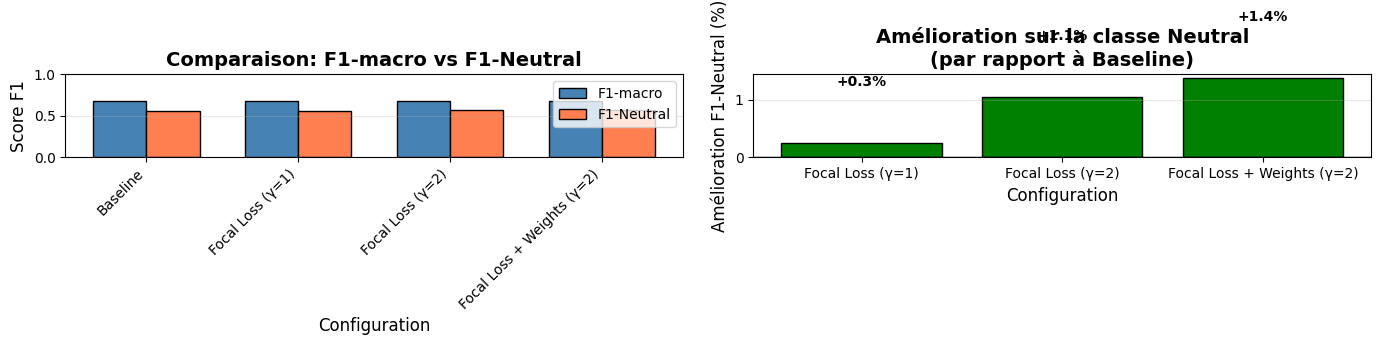

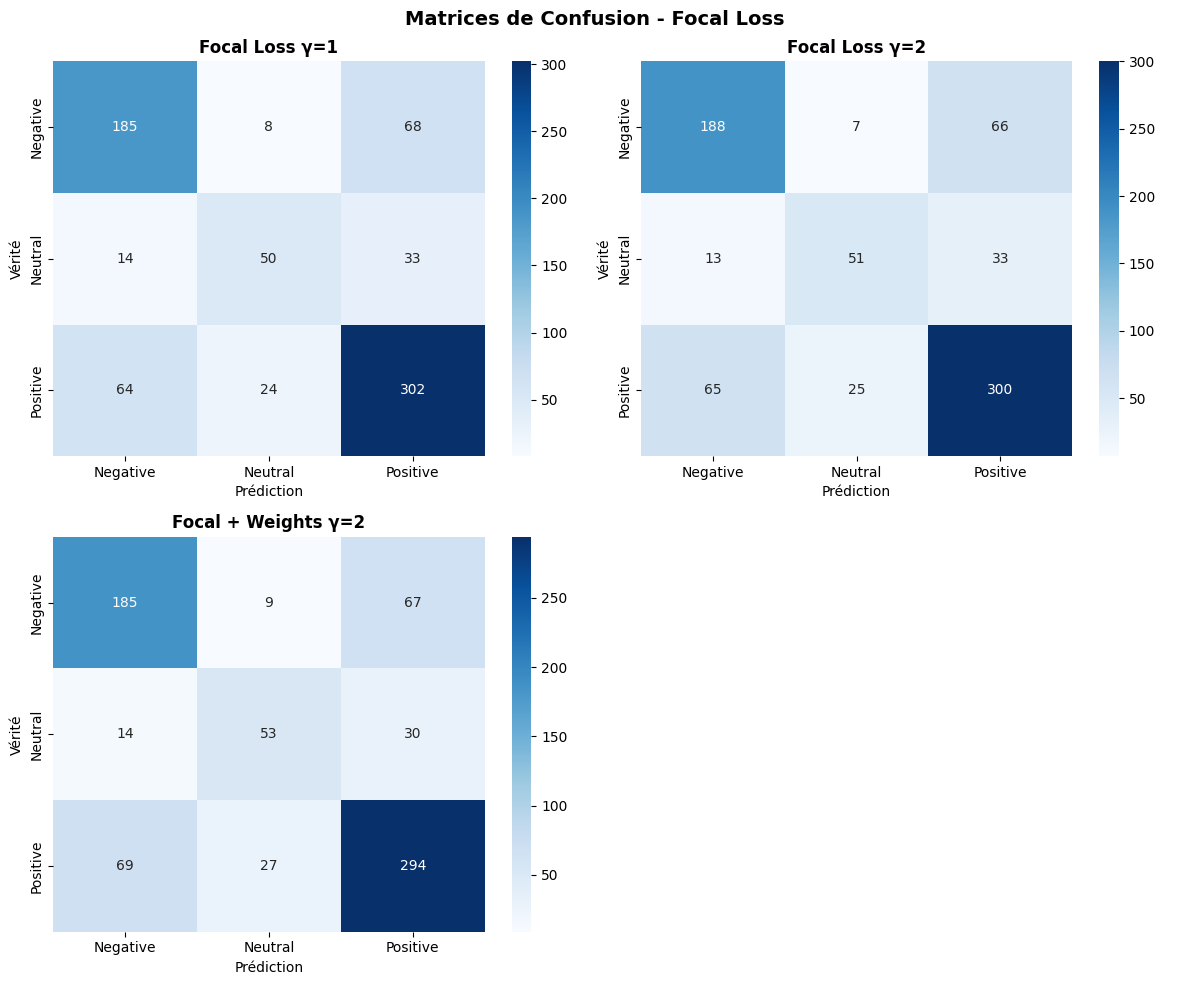


✓ Résultats sauvegardés:
  - focal_loss_results.json
  - comparison_focal_loss.csv

ANALYSE POUR LE RAPPORT
✓ STRATÉGIE 1 - FOCAL LOSS TERMINÉE


In [ ]:
# ============================================================
# 5. VARIANTE C: COMBINAISON (FOCAL LOSS γ=2 + CLASS WEIGHTS)
# ============================================================

print("\n" + "="*60)
print("VARIANTE C - FOCAL LOSS γ=2 + CLASS WEIGHTS")
print("="*60)

model_combined = get_fresh_model()

trainer_combined = FocalLossTrainer(
    gamma=2.0,
    class_weights=weights_tensor,  # Combiner avec les poids
    model=model_combined,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("\nEntraînement avec Focal Loss γ=2 + Class Weights...")
trainer_combined.train()
test_results_combined = trainer_combined.evaluate(test_dataset)

print("\n RÉSULTATS FOCAL LOSS γ=2 + CLASS WEIGHTS:")
print(f"  F1-macro: {test_results_combined['eval_f1_macro']:.4f}")
print(f"  F1-Neutral: {test_results_combined['eval_f1_neutral']:.4f}")

# ============================================================
# 6. TABLEAU COMPARATIF COMPLET
# ============================================================

print("\n" + "="*60)
print("TABLEAU COMPARATIF - BASELINE VS FOCAL LOSS")
print("="*60)

# Charger baseline
with open('baseline_results.json', 'r') as f:
    baseline = json.load(f)

# Créer le DataFrame de comparaison
comparison = pd.DataFrame({
    'Configuration': [
        'Baseline',
        'Focal Loss (γ=1)',
        'Focal Loss (γ=2)',
        'Focal Loss + Weights (γ=2)'
    ],
    'F1-macro': [
        baseline['f1_macro'],
        test_results_g1['eval_f1_macro'],
        test_results_g2['eval_f1_macro'],
        test_results_combined['eval_f1_macro']
    ],
    'F1-Positive': [
        baseline['f1_positive'],
        test_results_g1['eval_f1_positive'],
        test_results_g2['eval_f1_positive'],
        test_results_combined['eval_f1_positive']
    ],
    'F1-Negative': [
        baseline['f1_negative'],
        test_results_g1['eval_f1_negative'],
        test_results_g2['eval_f1_negative'],
        test_results_combined['eval_f1_negative']
    ],
    'F1-Neutral': [
        baseline['f1_neutral'],
        test_results_g1['eval_f1_neutral'],
        test_results_g2['eval_f1_neutral'],
        test_results_combined['eval_f1_neutral']
    ],
    'G-mean': [
        baseline['g_mean'],
        test_results_g1['eval_g_mean'],
        test_results_g2['eval_g_mean'],
        test_results_combined['eval_g_mean']
    ]
})

print("\n" + comparison.to_string(index=False))

# ============================================================
# 7. VISUALISATION COMPARATIVE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1: Comparaison F1-macro
configs = comparison['Configuration'].tolist()
f1_macro = comparison['F1-macro'].tolist()
f1_neutral = comparison['F1-Neutral'].tolist()

x = np.arange(len(configs))
width = 0.35

axes[0].bar(x - width/2, f1_macro, width, label='F1-macro', color='steelblue', edgecolor='black')
axes[0].bar(x + width/2, f1_neutral, width, label='F1-Neutral', color='coral', edgecolor='black')
axes[0].set_xlabel('Configuration', fontsize=12)
axes[0].set_ylabel('Score F1', fontsize=12)
axes[0].set_title('Comparaison: F1-macro vs F1-Neutral', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(configs, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# Graphique 2: Amélioration par rapport à baseline
improvement = []
for i in range(1, len(configs)):
    imp = (comparison['F1-Neutral'].iloc[i] - comparison['F1-Neutral'].iloc[0]) * 100
    improvement.append(imp)

# Plotting the improvement with corrected label positioning
bars = axes[1].bar(configs[1:], improvement, color=['green' if val > 0 else 'red' for val in improvement], edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Configuration', fontsize=12)
axes[1].set_ylabel('Amélioration F1-Neutral (%)', fontsize=12)
axes[1].set_title('Amélioration sur la classe Neutral\n(par rapport à Baseline)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add labels to the bars
for i, bar_rect in enumerate(bars):
    val = improvement[i]
    y_pos = bar_rect.get_height() + (1 if val > 0 else -3)
    axes[1].text(bar_rect.get_x() + bar_rect.get_width()/2, y_pos,
                f'{val:+.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# 8. MATRICES DE CONFUSION COMPARATIVES
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

trainers_and_names = [
    (trainer_g1, 'Focal Loss γ=1', axes[0, 0]),
    (trainer_g2, 'Focal Loss γ=2', axes[0, 1]),
    (trainer_combined, 'Focal + Weights γ=2', axes[1, 0])
]

# Baseline matrix
predictions_baseline = trainer.predict(test_dataset) if 'trainer' in dir() else None

for trainer, name, ax in trainers_and_names:
    predictions = trainer.predict(test_dataset)
    y_pred = np.argmax(predictions.predictions, axis=-1)
    y_true = predictions.label_ids
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Prédiction', fontsize=10)
    ax.set_ylabel('Vérité', fontsize=10)

axes[1, 1].axis('off')
plt.suptitle('Matrices de Confusion - Focal Loss', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 9. SAUVEGARDE DES RÉSULTATS
# ============================================================

# Sauvegarder tous les résultats
all_focal_results = {
    'gamma1': test_results_g1,
    'gamma2': test_results_g2,
    'gamma_3': test_results_g3,
    'combined': test_results_combined
}

with open('focal_loss_results.json', 'w') as f:
    json.dump(all_focal_results, f, indent=4)

# Sauvegarder le tableau comparatif
comparison.to_csv('comparison_focal_loss.csv', index=False)

print("\n✓ Résultats sauvegardés:")
print("  - focal_loss_results.json")
print("  - comparison_focal_loss.csv")

# ============================================================
# 10. ANALYSE POUR LE RAPPORT
# ============================================================

print("\n" + "="*60)
print("ANALYSE POUR LE RAPPORT")
print("="*60)

best_gamma = "γ=2" if test_results_g2['eval_f1_neutral'] > test_results_g1['eval_f1_neutral'] else "γ=1"
best_f1 = max(test_results_g1['eval_f1_neutral'], test_results_g2['eval_f1_neutral'], test_results_combined['eval_f1_neutral'])

print("="*60)
print("✓ STRATÉGIE 1 - FOCAL LOSS TERMINÉE")
print("="*60)


In [ ]:
# ============================================================
# SAUVEGARDE UNIQUE (DÉBUT)
# ============================================================

from google.colab import drive
import pickle
import pandas as pd
import json

drive.mount('/content/drive')

# 1. Sauvegarder les splits
train_set.to_csv('/content/drive/MyDrive/train_set.csv', index=False)
val_set.to_csv('/content/drive/MyDrive/val_set.csv', index=False)
test_set.to_csv('/content/drive/MyDrive/test_set.csv', index=False)

# 2. Sauvegarder les textes clean
with open('/content/drive/MyDrive/texts_labels.pkl', 'wb') as f:
    pickle.dump({
        'train_texts': train_set['clean_text'].tolist(),
        'train_labels': train_set['Polarity Class'].tolist(),
        'val_texts': val_set['clean_text'].tolist(),
        'val_labels': val_set['Polarity Class'].tolist(),
        'test_texts': test_set['clean_text'].tolist(),
        'test_labels': test_set['Polarity Class'].tolist()
    }, f)

# 3. Sauvegarder les résultats de la Stratégie 1 (déjà faits)
with open('/content/drive/MyDrive/strategy1_results.json', 'w') as f:
    json.dump({
        'baseline': baseline_results,
        'class_weighting': class_weighting_results if 'class_weighting_results' in dir() else None,
        'focal_loss_gamma1': float(test_results_g1['eval_f1_neutral']) if 'test_results_g1' in dir() else None,
        'focal_loss_gamma2': float(test_results_g2['eval_f1_neutral']) if 'test_results_g2' in dir() else None,
    }, f)

print("✓ Sauvegarde initiale terminée!")



ValueError: mount failed